
# Q5 Results Analysis

This section analyzes the results produced in **Q5 – Temporal Performance Analysis**.

Unlike previous experiments that used random train/test splits,
Q5 evaluates model performance across chronological time segments.


## Temporal Splits

The dataset contains a timestamp feature (**Time**) that represents the chronological order of transactions.

For the temporal analysis, all transactions were first sorted by time and then divided into consecutive time segments.

Each time segment occurs sequentially, using n = 20% of the data step size:

* **Split 1:** Train on **T₀ → Tₙ**, test on **Tₙ₊₁ → T₂ₙ**.
* **Split 2:** Train on **T₀ → T₂ₙ**, test on **T₂ₙ₊₁ → T₃ₙ**.
* **Split 3:** Train on **T₀ → T₃ₙ**, test on **T₃ₙ₊₁ → T₄ₙ**.
* **Split 4:** Train on **T₀ → T₄ₙ**, test on **T₄ₙ₊₁ → T₅ₙ**.
* **Split 5:** Train on **T₀ → T₅ₙ**, test on **T₅ₙ₊₁ → T₆ₙ** 

**Note:** Later splits have a bigger train size


For every split, the model was trained using transactions from all previous time periods and evaluated on transactions from the next unseen time period.

This approach simulates a real-world scenario where a fraud detection model learns from historical transactions and is then required to detect fraud in future transactions.




## Load Experiment Results

Load temporal performance results and feature drift analysis generated during Q5.


In [57]:

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [58]:
current_path = Path.cwd()

while current_path.name != "MachineLearningProject":
    current_path = current_path.parent

PROJECT_ROOT = current_path


In [59]:
q5_results = pd.read_csv(
    PROJECT_ROOT / "out" / "Q5_results.csv"
)

q5_drift = pd.read_csv(
    PROJECT_ROOT / "out" / "Q5_feature_drift.csv"
)

print(f"Results rows: {len(q5_results)}")
print(f"Drift rows: {len(q5_drift)}")

q5_results.head()


Results rows: 5
Drift rows: 30


,split,train_samples,test_samples,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,1,47467,47467,0.999537,0.945455,0.732394,0.825397,0.923167,0.809166,47393,3,19,52
1,2,94934,47467,0.999621,0.869565,0.769231,0.816327,0.929415,0.704896,47409,6,12,40
2,3,142401,47467,0.999094,0.845238,0.702970,0.767568,0.977737,0.762233,47353,13,30,71
3,4,189868,47467,0.999579,0.886792,0.770492,0.824561,0.967292,0.794313,47400,6,14,47
4,5,237335,47472,0.999558,0.884615,0.754098,0.814159,0.950070,0.790241,47405,6,15,46



## Dataset Overview

Inspect the temporal experiment structure before continuing.

Each row corresponds to one forward temporal split.


In [60]:

q5_results.info()

q5_results.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   split            5 non-null      int64  
 1   train_samples    5 non-null      int64  
 2   test_samples     5 non-null      int64  
 3   accuracy         5 non-null      float64
 4   precision        5 non-null      float64
 5   recall           5 non-null      float64
 6   f1               5 non-null      float64
 7   roc_auc          5 non-null      float64
 8   pr_auc           5 non-null      float64
 9   true_negatives   5 non-null      int64  
 10  false_positives  5 non-null      int64  
 11  false_negatives  5 non-null      int64  
 12  true_positives   5 non-null      int64  
dtypes: float64(6), int64(7)
memory usage: 648.0 bytes


,split,train_samples,test_samples,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000
mean,3.000000,142401.000000,47468.000000,0.999478,0.886333,0.745837,0.809602,0.949536,0.772170,47392.000000,6.800000,18.00000,51.200000
std,1.581139,75051.916848,2.236068,0.000217,0.036975,0.028468,0.024011,0.023511,0.041262,22.605309,3.701351,7.17635,11.861703
min,1.000000,47467.000000,47467.000000,0.999094,0.845238,0.702970,0.767568,0.923167,0.704896,47353.000000,3.000000,12.00000,40.000000
25%,2.000000,94934.000000,47467.000000,0.999537,0.869565,0.732394,0.814159,0.929415,0.762233,47393.000000,6.000000,14.00000,46.000000
50%,3.000000,142401.000000,47467.000000,0.999558,0.884615,0.754098,0.816327,0.950070,0.790241,47400.000000,6.000000,15.00000,47.000000
75%,4.000000,189868.000000,47467.000000,0.999579,0.886792,0.769231,0.824561,0.967292,0.794313,47405.000000,6.000000,19.00000,52.000000
max,5.000000,237335.000000,47472.000000,0.999621,0.945455,0.770492,0.825397,0.977737,0.809166,47409.000000,13.000000,30.00000,71.000000



## Temporal Performance Comparison

To better evaluate the model's stability over time, multiple performance metrics are plotted together across all temporal splits. This visualization allows us to compare how Precision, Recall, F1-Score, and PR-AUC evolve throughout different time periods and helps identify potential performance degradation or concept drift.


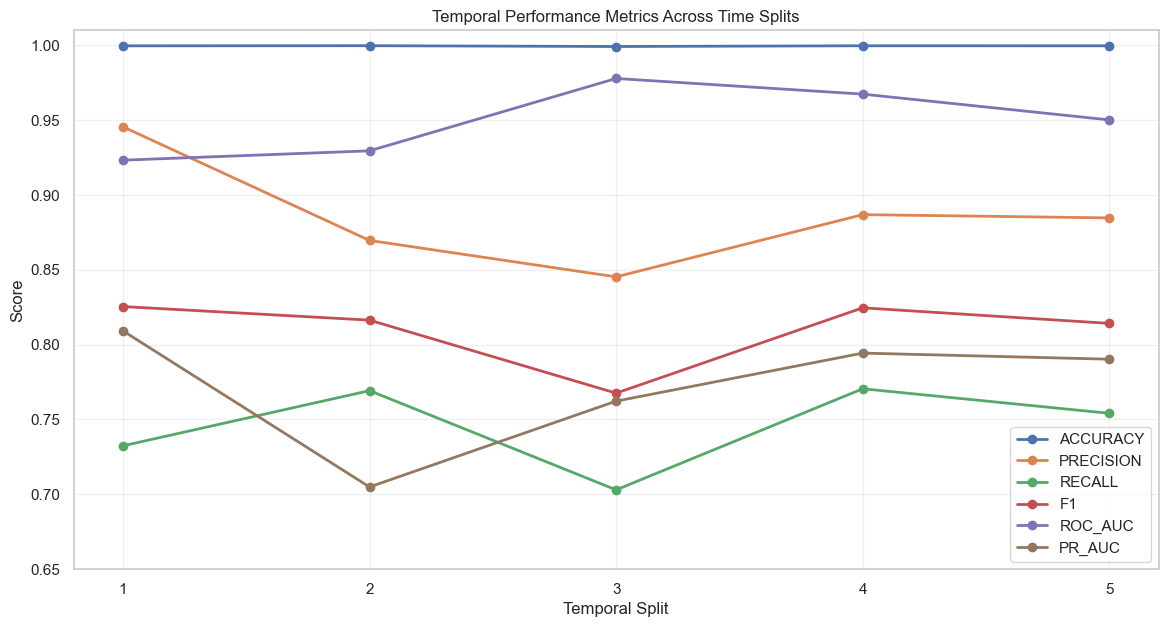

In [61]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]

plt.figure(figsize=(14,7))

for metric in metrics:
    plt.plot(
        q5_results["split"],
        q5_results[metric],
        marker="o",
        linewidth=2,
        label=metric.upper()
    )

plt.title("Temporal Performance Metrics Across Time Splits")
plt.xlabel("Temporal Split")
plt.ylabel("Score")
plt.xticks(q5_results["split"])
plt.ylim(0.65, 1.01)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


## Interpretation:

Temporal split 4 in our opinion has the best score (highest recall, with a reasonably high precision)


# Missed Fraud Cases

False negatives represent fraud transactions that the model failed to detect.

An increasing number of false negatives over time is a strong indicator of concept drift.


/tmp/ipykernel_15532/1914220580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


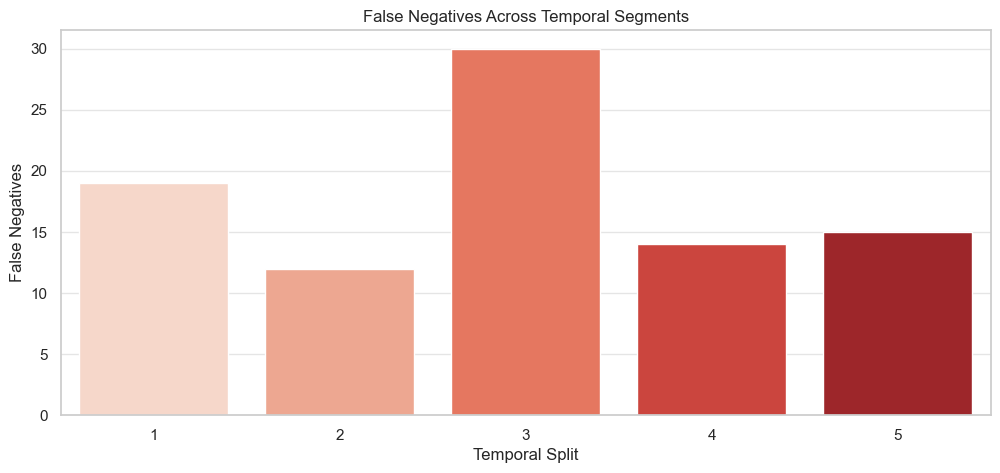

In [62]:

plt.figure(figsize=(12,5))

sns.barplot(
    data=q5_results,
    x="split",
    y="false_negatives",
    palette="Reds"
)

plt.title("False Negatives Across Temporal Segments")
plt.xlabel("Temporal Split")
plt.ylabel("False Negatives")

plt.show()



# Feature Importance Drift

This section investigates whether the model relies on the same features throughout time.

Large drift values imply fraud patterns evolve across temporal segments.


In [63]:

q5_drift.sort_values(
    "drift_score",
    ascending=False
).head(10)


,feature,mean_importance,std_importance,drift_score
3,V3,0.095107,0.032186,0.023708
0,V14,0.209694,0.010084,0.010417
5,V4,0.089611,0.008957,0.009165
2,V12,0.105246,0.009695,0.009085
7,V16,0.045853,0.006757,0.007948
13,V6,0.008880,0.009205,0.007244
6,V11,0.049584,0.006390,0.007222
4,V17,0.091485,0.008553,0.007089
9,V9,0.023502,0.004600,0.007062
8,V2,0.045199,0.009065,0.006723



## Most Dynamic Features

These features change importance the most across time.


In [64]:

top_drift = (
    q5_drift
    .sort_values(
        "drift_score",
        ascending=False
    )
    .head(10)
)


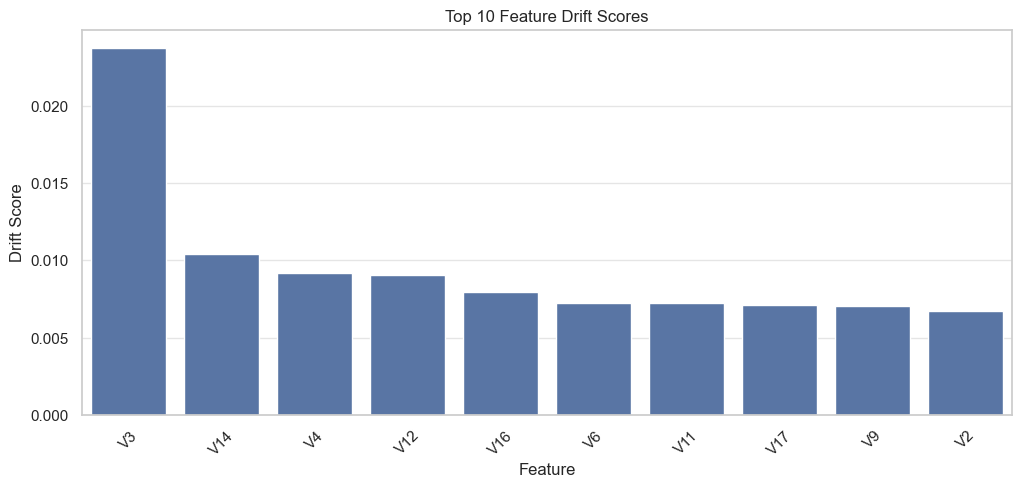

In [65]:

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_drift,
    x="feature",
    y="drift_score"
)

plt.title(
    "Top 10 Feature Drift Scores"
)

plt.xlabel("Feature")
plt.ylabel("Drift Score")

plt.xticks(rotation=45)

plt.show()


## Note:

We calculate the drift score by calculating the difference between its current split's importance to the previous one, then we normalize the sum of all the changes to obtain the score 


## Most Stable Features

Stable features remain important regardless of temporal segment.


In [66]:

stable_features = (
    q5_drift
    .sort_values(
        "std_importance"
    )
    .head(10)
)


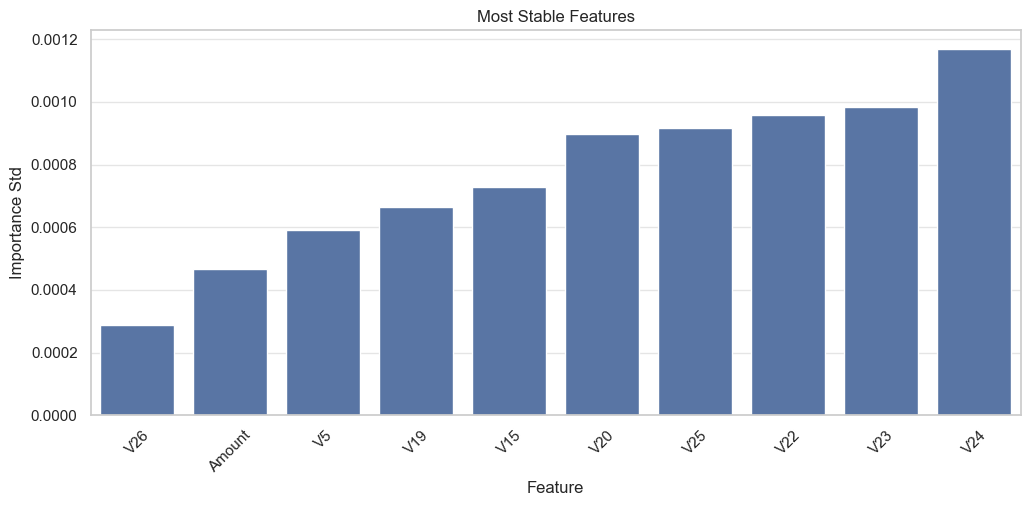

In [67]:

plt.figure(figsize=(12,5))

sns.barplot(
    data=stable_features,
    x="feature",
    y="std_importance"
)

plt.title(
    "Most Stable Features"
)

plt.xlabel("Feature")
plt.ylabel("Importance Std")

plt.xticks(rotation=45)

plt.show()



## Feature Drift Heatmap

Visual representation of average feature importance and drift.


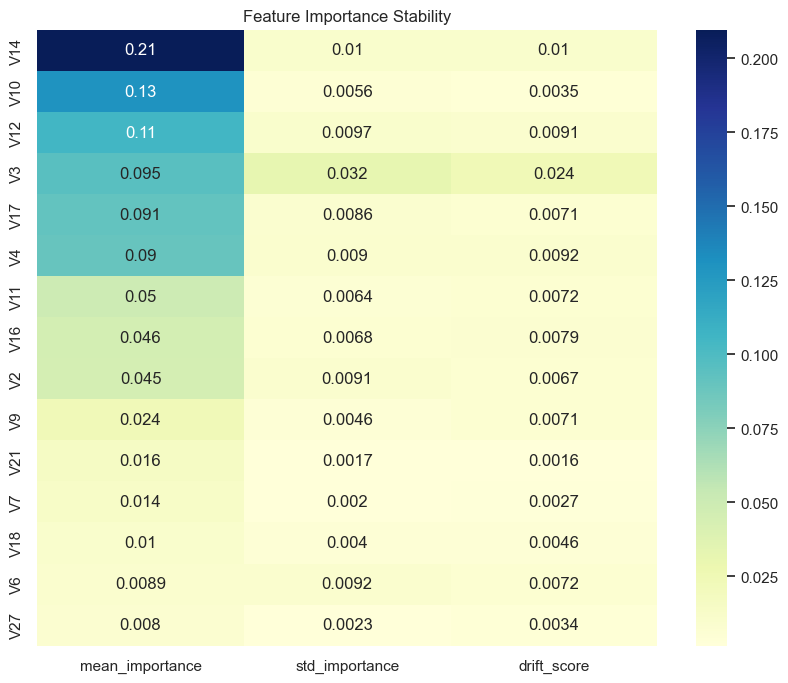

In [68]:

heatmap_df = (
    q5_drift
    .sort_values(
        "mean_importance",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_df[
        [
            "mean_importance",
            "std_importance",
            "drift_score"
        ]
    ],
    annot=True,
    cmap="YlGnBu",
    yticklabels=heatmap_df["feature"]
)

plt.title(
    "Feature Importance Stability"
)

plt.show()



## Q5 Conclusion

The temporal analysis indicates that the selected fraud detection model maintains relatively stable performance across different time periods. Recall values ranged from approximately 70% to 77%, while Precision remained consistently high between 84% and 95%, demonstrating that the model continues to identify fraudulent transactions effectively over time.

Although performance fluctuates slightly between temporal splits, no clear downward trend is observed in Recall, PR-AUC, or F1-Score. This suggests that the model's ability to detect fraud does not deteriorate as the testing data moves further into the future.

Split 3 appears to be the most challenging period, showing the lowest Recall (0.703) and the highest number of False Negatives (30). However, subsequent splits recover to performance levels similar to earlier periods, indicating a temporary variation rather than a systematic decline.

The feature importance analysis also supports this conclusion. The most influential features, particularly **V14**, **V10**, and **V12**, remain consistently important across all temporal periods. While some variation exists, especially for **V3**, the overall feature importance rankings remain stable.

Overall, the results provide little evidence of significant concept drift. The fraud patterns captured by the model appear to remain largely consistent throughout the dataset, and the model demonstrates strong temporal robustness. Therefore, within the observed time horizon, frequent retraining does not appear to be necessary, although periodic monitoring is still recommended to detect future changes in fraud behavior.
